In [1]:
import pandas as pd

df = pd.read_csv("data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Business Assumptions and Context

# ---- Business Assumptions ---- #

AVG_FRAUD_LOSS = 120      # average loss per fraud transaction (£)
FALSE_POSITIVE_COST = 5   # operational + customer friction cost (£)
MIN_APPROVAL_RATE = 0.98  # must approve at least 98% of transactions
MAX_FPR = 0.002           # 0.2% maximum false positive rate

## Fraud Distribution Overview

In [2]:
total_transactions = len(df)
total_fraud = df["Class"].sum()
fraud_rate = total_fraud / total_transactions

print("Total transactions:", total_transactions)
print("Total fraud cases:", total_fraud)
print("Fraud rate:", round(fraud_rate * 100, 4), "%")

Total transactions: 284807
Total fraud cases: 492
Fraud rate: 0.1727 %


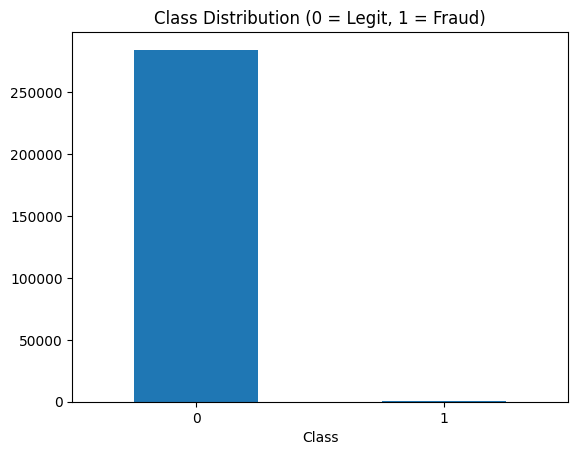

In [3]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.xticks(rotation=0)
plt.show()

## Train / Validation / Test Split

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    stratify=y, 
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    stratify=y_temp, 
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (199364, 30)
Validation size: (42721, 30)
Test size: (42722, 30)


## Verifying Fraud Distribution in Each Split

In [5]:
print("Train fraud rate:", round(y_train.mean()*100, 4), "%")
print("Validation fraud rate:", round(y_val.mean()*100, 4), "%")
print("Test fraud rate:", round(y_test.mean()*100, 4), "%")

Train fraud rate: 0.1725 %
Validation fraud rate: 0.1732 %
Test fraud rate: 0.1732 %


## Baseline Model - LightGBM

In [6]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

# Handle imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

# Predict probabilities
val_probs = model.predict_proba(X_val)[:, 1]

# Evaluate
roc = roc_auc_score(y_val, val_probs)
pr_auc = average_precision_score(y_val, val_probs)

print("Validation ROC-AUC:", round(roc, 4))
print("Validation PR-AUC:", round(pr_auc, 4))

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024634 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001725 -> initscore=-6.360519
[LightGBM] [Info] Start training from score -6.360519
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [7]:
import sys
!{sys.executable} -m pip install lightgbm

In [8]:
import lightgbm as lgb